In [1]:
!pip -q install qiskit qiskit-aer pylatexenc matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.7 MB/s eta 0:00:00


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

sim = AerSimulator()

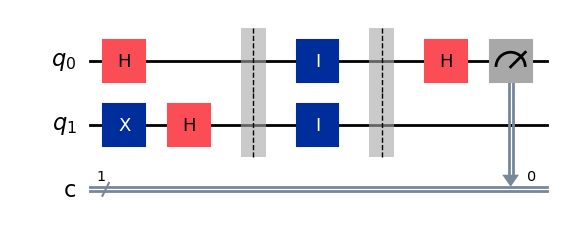

Measurement result: {'0': 1000}
Function identified as CONSTANT


In [3]:
# Exercise 1: Deutsch Algorithm for f(x) = 0

qc1 = QuantumCircuit(2, 1)

# Ancilla starts in |1>
qc1.x(1)

# Prepare superposition
qc1.h(0)
qc1.h(1)

qc1.barrier()

# Oracle for f(x) = 0
# U_f |x,y> = |x,y>
qc1.id(0)
qc1.id(1)

qc1.barrier()

# Interference
qc1.h(0)

# Measure input qubit
qc1.measure(0, 0)

display(qc1.draw("mpl"))

# Execute
compiled1 = transpile(qc1, sim)

result1 = sim.run(
    compiled1,
    shots=1000
).result()

counts1 = result1.get_counts()

print("Measurement result:", counts1)

if counts1.get("0", 0) > counts1.get("1", 0):
    print("Function identified as CONSTANT")
else:
    print("Function identified as BALANCED")

plot_histogram(counts1)
plt.show()

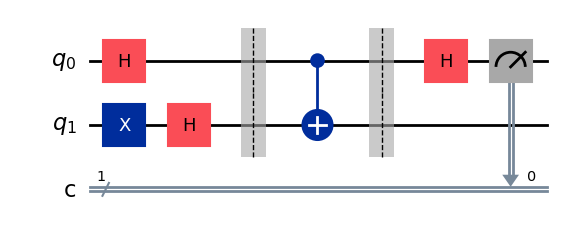

Measurement result: {'1': 1000}
Measured output: 1
Function type: BALANCED


In [4]:
# Exercise 2: Deutsch Algorithm for f(x) = x

qc2 = QuantumCircuit(2, 1)

# Initialize ancilla to |1>
qc2.x(1)

# Apply Hadamard gates
qc2.h([0, 1])

qc2.barrier()

# Oracle for f(x) = x
qc2.cx(0, 1)

qc2.barrier()

# Final Hadamard
qc2.h(0)

# Measure input qubit
qc2.measure(0, 0)

display(qc2.draw("mpl"))

# Run simulator
compiled2 = transpile(qc2, sim)

counts2 = sim.run(
    compiled2,
    shots=1000
).result().get_counts()

print("Measurement result:", counts2)

answer = max(counts2, key=counts2.get)

print("Measured output:", answer)

if answer == "0":
    print("Function type: CONSTANT")
else:
    print("Function type: BALANCED")

plot_histogram(counts2)
plt.show()


-----------------------------
f(x) = 0
Counts: {'0': 512}
Classification: CONSTANT


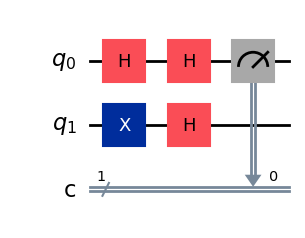


-----------------------------
f(x) = 1
Counts: {'0': 512}
Classification: CONSTANT


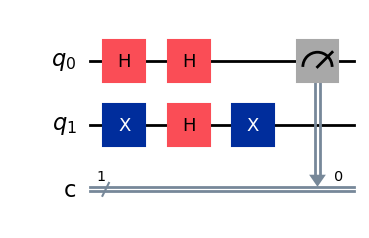


-----------------------------
f(x) = x
Counts: {'1': 512}
Classification: BALANCED


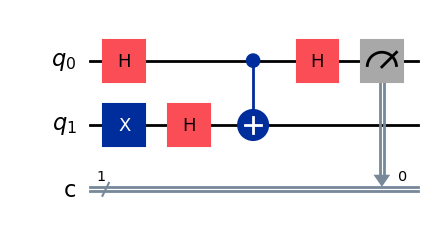


-----------------------------
f(x) = NOT x
Counts: {'1': 512}
Classification: BALANCED


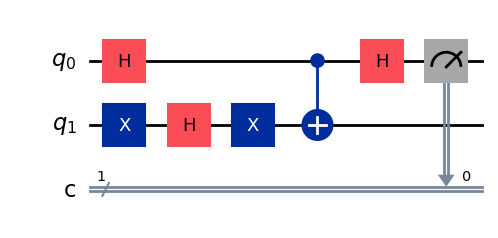

In [5]:
# Exercise 3: Generic oracle generator

def oracle_from_id(function_id):

    oracle = QuantumCircuit(2)

    # 0 -> f(x) = 0
    if function_id == 0:
        pass

    # 1 -> f(x) = 1
    elif function_id == 1:
        oracle.x(1)

    # 2 -> f(x) = x
    elif function_id == 2:
        oracle.cx(0, 1)

    # 3 -> f(x) = NOT x
    elif function_id == 3:
        oracle.x(1)
        oracle.cx(0, 1)

    else:
        raise ValueError("Function ID must be 0, 1, 2 or 3.")

    return oracle


function_names = {
    0: "f(x) = 0",
    1: "f(x) = 1",
    2: "f(x) = x",
    3: "f(x) = NOT x"
}


for function_id in range(4):

    circuit = QuantumCircuit(2, 1)

    # Ancilla = |1>
    circuit.x(1)

    # Initial Hadamards
    circuit.h(0)
    circuit.h(1)

    # Dynamically create oracle
    selected_oracle = oracle_from_id(function_id)

    circuit.compose(
        selected_oracle,
        qubits=[0, 1],
        inplace=True
    )

    # Final interference
    circuit.h(0)

    # Measurement
    circuit.measure(0, 0)

    compiled = transpile(circuit, sim)

    counts = sim.run(
        compiled,
        shots=512
    ).result().get_counts()

    measured_bit = max(counts, key=counts.get)

    classification = (
        "CONSTANT"
        if measured_bit == "0"
        else "BALANCED"
    )

    print("\n-----------------------------")
    print(function_names[function_id])
    print("Counts:", counts)
    print("Classification:", classification)

    display(circuit.draw("mpl"))

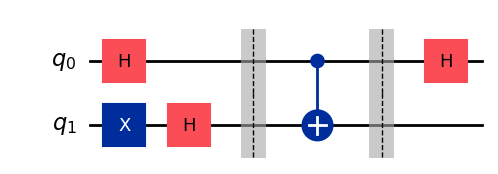

Conceptual Process:
|x> -> Binary Oracle -> Phase Kickback -> Interference

Oracle decision:
x = 0 -> Class 0
x = 1 -> Class 1


In [6]:
# Exercise 4:
# Conceptual binary classification using phase kickback

classifier = QuantumCircuit(2)

# Input qubit represents a binary feature
classifier.h(0)

# Ancilla preparation
classifier.x(1)
classifier.h(1)

classifier.barrier()

# Example binary classification oracle
# class(x) = x
classifier.cx(0, 1)

classifier.barrier()

# Convert phase information to amplitude information
classifier.h(0)

display(classifier.draw("mpl"))

print("Conceptual Process:")
print("|x> -> Binary Oracle -> Phase Kickback -> Interference")
print()
print("Oracle decision:")
print("x = 0 -> Class 0")
print("x = 1 -> Class 1")

Error =  0°  Counts = {'1': 2000}  Reliability = 1.000
Error =  5°  Counts = {'0': 5, '1': 1995}  Reliability = 0.998
Error = 10°  Counts = {'0': 12, '1': 1988}  Reliability = 0.994
Error = 15°  Counts = {'0': 26, '1': 1974}  Reliability = 0.987
Error = 20°  Counts = {'0': 75, '1': 1925}  Reliability = 0.963
Error = 30°  Counts = {'0': 140, '1': 1860}  Reliability = 0.930
Error = 40°  Counts = {'0': 227, '1': 1773}  Reliability = 0.886
Error = 50°  Counts = {'1': 1611, '0': 389}  Reliability = 0.805


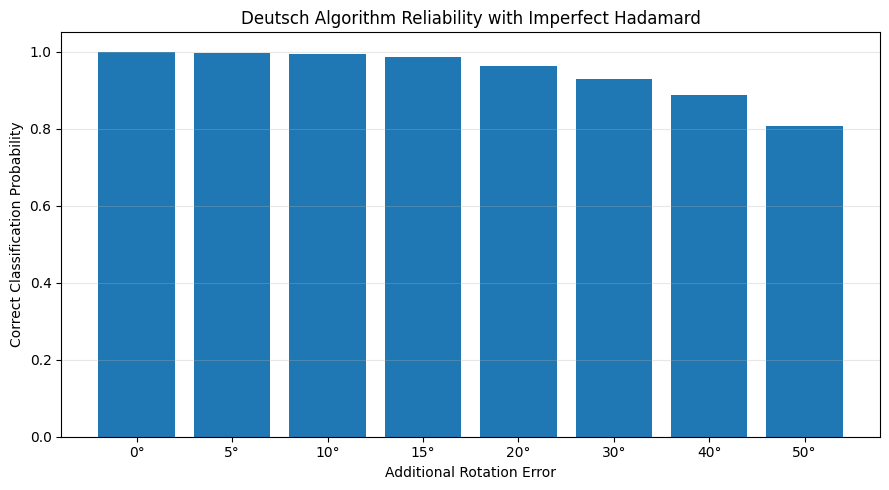

In [7]:
# Exercise 5:
# Imperfect Hadamard experiment

error_angles = [
    0,
    5,
    10,
    15,
    20,
    30,
    40,
    50
]

shots = 2000

success_rates = []

for degrees in error_angles:

    experiment = QuantumCircuit(2, 1)

    # Prepare ancilla
    experiment.x(1)

    # Initial ideal Hadamards
    experiment.h(0)
    experiment.h(1)

    # Balanced oracle f(x) = x
    experiment.cx(0, 1)

    # Ideal final Hadamard
    experiment.h(0)

    # Deliberate gate error
    error_radians = np.radians(degrees)

    experiment.ry(
        error_radians,
        0
    )

    # Measurement
    experiment.measure(0, 0)

    compiled = transpile(
        experiment,
        sim
    )

    counts = sim.run(
        compiled,
        shots=shots
    ).result().get_counts()

    # Balanced function should ideally produce 1
    correct_results = counts.get("1", 0)

    success = correct_results / shots

    success_rates.append(success)

    print(
        f"Error = {degrees:2d}°  "
        f"Counts = {counts}  "
        f"Reliability = {success:.3f}"
    )


# ----------------------------
# Bar Chart
# ----------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    [str(angle) + "°" for angle in error_angles],
    success_rates
)

plt.xlabel("Additional Rotation Error")

plt.ylabel("Correct Classification Probability")

plt.title(
    "Deutsch Algorithm Reliability "
    "with Imperfect Hadamard"
)

plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()